# Showcase data

- Generate a table showing the data distribution across all experiments. Positions 100-199 were untreated, and positions 200-299 were treated with antibiotics.
- Show the time-lapse from a specified data instance, corresponding to a chamber.


In [7]:
import imgtool
print(imgtool.__file__)  # Check where it's being imported from
print(dir(imgtool))

c:\Users\silve\Documents\210\scripts\imgtool.py
['BytesIO', 'CACHE_ROOT', 'IPython', 'List', 'Optional', 'PIL', 'Tuple', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'base64', 'blur', 'filters', 'gb', 'glob', 'imageio', 'ld', 'logging', 'makesameshape', 'natsorted', 'nm', 'np', 'os', 'pad_or_crop', 'plt', 'rz', 'saveimg', 'skimage', 'sw', 'swvid']


In [1]:
import sys
sys.executable

'c:\\Users\\silve\\AppData\\Local\\Programs\\Python\\Python311\\python.exe'

In [2]:
import os
import sys

import numpy as np

sys.path.insert(0, os.path.expanduser("scripts"))
import albumentations as A
import cv2
import dataloader
import imgtool as t
import pandas as pd

C:\Users\silve\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
height_crop = 352
width_crop = 52
top_stop_location = 32
dataset_settings = {
    "data_folder_location": os.path.join(os.getcwd(), "data"),
    "label_folder_location": os.path.join(os.getcwd(), "data/selections"),
    "n_frames": 1,
    "random_seed": 42,
    "test_frame_idx": 0,
    "train_frac": 0.85,
    "shuffle_frames": False,
    "is_video_resnet": False,
    "test_aug": [
        A.Crop(
            y_min=top_stop_location,
            y_max=top_stop_location + height_crop,
            x_max=width_crop,
        ),
        A.SmallestMaxSize(max_size=width_crop, interpolation=cv2.INTER_LANCZOS4),
        A.Normalize(mean=(0.43216), std=(0.22803), max_pixel_value=1.0),
    ],
    "train_aug": [
        A.Crop(y_min=top_stop_location, y_max=800, x_max=width_crop),
        A.ShiftScaleRotate(p=0.5, rotate_limit=3),
        A.RandomBrightnessContrast(p=0.5),
        A.RandomCrop(height=height_crop, width=width_crop),
        A.HorizontalFlip(p=0.5),
        A.SmallestMaxSize(max_size=width_crop, interpolation=cv2.INTER_LANCZOS4),
        A.Normalize(mean=(0.43216), std=(0.22803), max_pixel_value=1.0),
    ],
}
trainset = dataloader.BacteriaClassificationDataset(**dataset_settings)
testset = dataloader.BacteriaClassificationDataset(testset=True, **dataset_settings)

C:\Users\silve\AppData\Roaming\Python\Python311\site-packages\albumentations\core\validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
table = pd.DataFrame()

for expidx, exp in enumerate(t.gb("data/Cropped-png*"), 1):
    acc = 0
    col = 0
    for spc in ["488", "CY3", "cy5", "txr"]:
        # Chambers in positions 100-199 were untreated
        # Chambers in positions 200-299 were treated with antibiotics
        for treat in ["2", "1"]:
            include = f"{exp}/Pos{treat}"

            num_train = len(
                [t for t in trainset.all_traps if include in t[0] and t[1] == spc]
            )
            num_test = len(
                [t for t in testset.all_traps if include in t[0] and t[1] == spc]
            )

            colname = f"{spc}-{treat}"
            table.loc[expidx, colname] = int(num_train + num_test)

for c in table.columns:
    table[c] = table[c].astype(int)

table.loc["Total"] = table.sum()
table["All species"] = table.loc[:].sum(axis=1)

print(table.to_latex(index=False, escape=False, header=False))

\begin{tabular}{rrrrrrrrr}
\toprule
\midrule
11 & 12 & 51 & 41 & 3 & 261 & 132 & 90 & 601 \\
38 & 60 & 0 & 1 & 6 & 183 & 90 & 60 & 438 \\
51 & 91 & 20 & 116 & 0 & 191 & 2 & 12 & 483 \\
108 & 66 & 67 & 105 & 0 & 201 & 4 & 4 & 555 \\
15 & 15 & 35 & 72 & 1 & 142 & 74 & 49 & 403 \\
6 & 78 & 7 & 41 & 0 & 1 & 1 & 5 & 139 \\
83 & 50 & 8 & 206 & 0 & 292 & 109 & 30 & 778 \\
312 & 372 & 188 & 582 & 10 & 1271 & 412 & 250 & 3397 \\
\bottomrule
\end{tabular}



In [5]:
table

,488-2,488-1,CY3-2,CY3-1,cy5-2,cy5-1,txr-2,txr-1,All species
1,11,12,51,41,3,261,132,90,601
2,38,60,0,1,6,183,90,60,438
3,51,91,20,116,0,191,2,12,483
4,108,66,67,105,0,201,4,4,555
5,15,15,35,72,1,142,74,49,403
6,6,78,7,41,0,1,1,5,139
7,83,50,8,206,0,292,109,30,778
Total,312,372,188,582,10,1271,412,250,3397


## Show the timelapse in two traps

('c:\\Users\\silve\\Documents\\210\\data\\Cropped-png-EXP-20-BV6126 AST FISH 201116/Pos164/trap-41_id-5083-19', 'cy5')



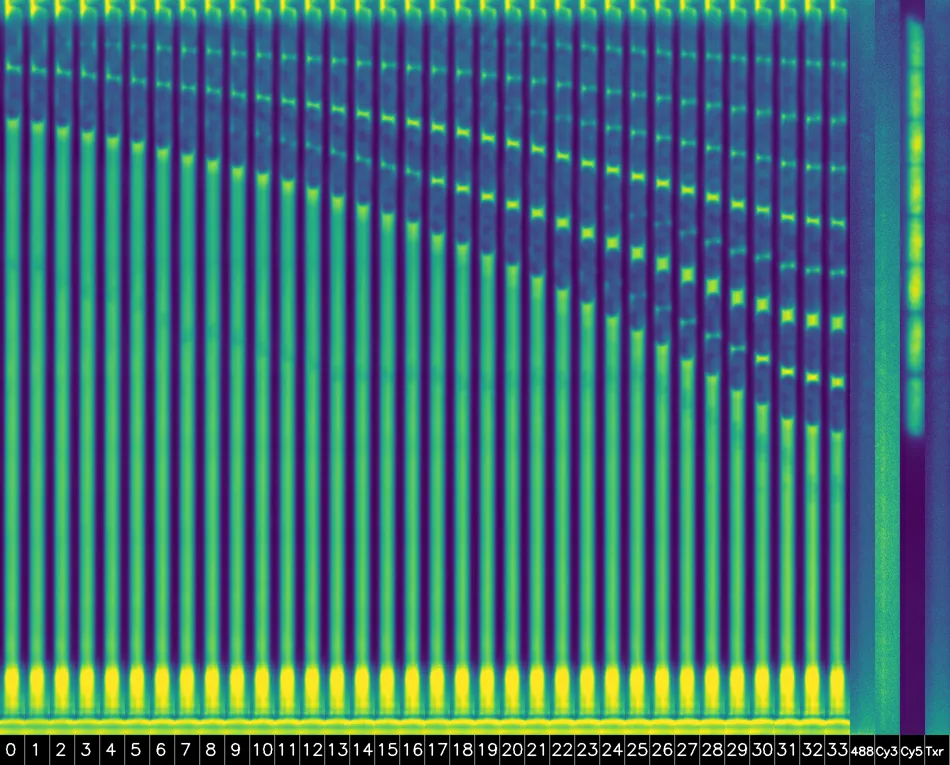

('c:\\Users\\silve\\Documents\\210\\data\\Cropped-png-EXP-20-BV6126 AST FISH 201116/Pos240/trap-37_id-2686-15', 'CY3')



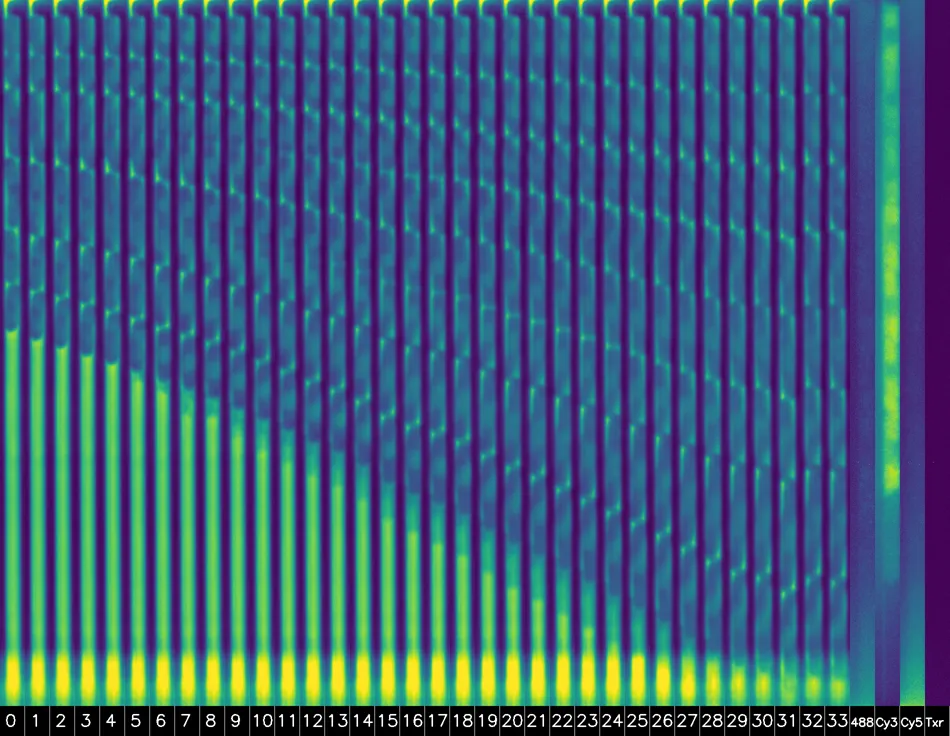

In [6]:
testset.show_all_frames_and_flour(0);
testset.show_all_frames_and_flour(100);